# 01 — Non-Personalized Recommender
**Contributors:** Sofia Navarro · Marco Vidal  
**Group 2 | Inside Airbnb Madrid — Apartment Recommendation System**

### Notebook Overview
1. Data loading & cleaning
2. Exploratory Data Analysis (8 visualisations)
3. Non-personalised recommender: Raw Average, Bayesian Average, Value-Weighted
4. Neighbourhood-filtered recommendations
5. Evaluation: RMSE, MAE, Precision@10, Recall@10, NDCG@10

**Dataset:** Inside Airbnb Madrid — `listings.csv.gz` + `reviews.csv` in `data/`

In [7]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as mticker, seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
print('✓ Libraries loaded')

✓ Libraries loaded


In [8]:
# ── Load files ────────────────────────────────────────────────────────────────
# Adjust the paths below if your files are in a different location
# Google Colab:  '/content/listings.csv.gz'
# Local Jupyter: 'data/listings.csv.gz'

listings = pd.read_csv('data/listings.csv.gz', low_memory=False)
reviews  = pd.read_csv('data/reviews.csv',     low_memory=False)
reviews['date'] = pd.to_datetime(reviews['date'])

print(f'Listings : {len(listings):,} rows × {listings.shape[1]} columns')
print(f'Reviews  : {len(reviews):,} rows')

# ── Clean price ───────────────────────────────────────────────────────────────
listings['price_clean'] = (
    listings['price']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)
# Remove extreme outliers (> €2,000/night)
listings = listings[listings['price_clean'].isna() | (listings['price_clean'] <= 2000)].copy()

# ── Clean review scores ───────────────────────────────────────────────────────
score_cols = [
    'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location',
    'review_scores_value', 'review_scores_checkin', 'review_scores_communication'
]
for col in score_cols:
    listings[col] = pd.to_numeric(listings[col], errors='coerce')

# Impute missing ratings: neighbourhood mean, then global mean
listings['review_scores_rating'] = (
    listings.groupby('neighbourhood_cleansed')['review_scores_rating']
    .transform(lambda x: x.fillna(x.mean()))
    .fillna(listings['review_scores_rating'].mean())
)
for col in score_cols[1:]:
    listings[col] = listings[col].fillna(4.5)

# ── Boolean flags ─────────────────────────────────────────────────────────────
listings['is_superhost']    = (listings['host_is_superhost'] == 't').astype(int)
listings['is_instant_book'] = (listings['instant_bookable']  == 't').astype(int)

# ── Host rate columns (strip % → float 0–1) ───────────────────────────────────
for col in ['host_response_rate', 'host_acceptance_rate']:
    listings[col] = (
        pd.to_numeric(listings[col].astype(str).str.replace('%', ''), errors='coerce')
        .fillna(80) / 100
    )

# ── Numeric conversions ───────────────────────────────────────────────────────
for col in ['accommodates', 'bedrooms', 'beds', 'number_of_reviews',
            'host_listings_count', 'minimum_nights']:
    listings[col] = pd.to_numeric(listings[col], errors='coerce')

listings['number_of_reviews'] = listings['number_of_reviews'].fillna(0)
listings['accommodates']      = listings['accommodates'].fillna(2)
listings['minimum_nights']    = listings['minimum_nights'].fillna(1).clip(1, 365)
listings['bedrooms']          = listings['bedrooms'].fillna(1)
listings['price_clean']       = listings['price_clean'].fillna(listings['price_clean'].median())

# Host seniority in years
listings['host_since'] = pd.to_datetime(listings['host_since'], errors='coerce')
listings['host_years'] = (
    (pd.Timestamp('2025-01-01') - listings['host_since']).dt.days / 365.25
).clip(0, 20).fillna(3)

# ── Amenity binary flags ──────────────────────────────────────────────────────
amenity_map = {
    'wifi'    : r'wifi|wi-fi',
    'kitchen' : r'kitchen',
    'ac'      : r'air conditioning|air-conditioning',
    'heating' : r'heating',
    'washer'  : r'washer|washing machine',
    'tv'      : r'\btv\b|television',
    'parking' : r'parking|garage',
    'elevator': r'elevator|lift',
    'gym'     : r'\bgym\b|fitness center',
    'pets'    : r'pets allowed',
}
amenities_str = listings['amenities'].fillna('').str.lower()
for name, pattern in amenity_map.items():
    listings[f'am_{name}'] = amenities_str.str.contains(pattern, regex=True).astype(int)

# ── Bayesian average (used across all recommenders) ───────────────────────────
C = listings['review_scores_rating'].mean()   # global mean
m = 50                                         # regularisation threshold
listings['bayesian_avg'] = (
    (listings['number_of_reviews'] / (listings['number_of_reviews'] + m))
    * listings['review_scores_rating']
    + (m / (listings['number_of_reviews'] + m)) * C
)

# ── Train / test temporal split ───────────────────────────────────────────────
SPLIT_DATE = pd.Timestamp('2024-07-01')
train_rev = reviews[reviews['date'] <  SPLIT_DATE].copy()
test_rev  = reviews[reviews['date'] >= SPLIT_DATE].copy()

print(f'\nAfter cleaning: {len(listings):,} listings')
print(f'Price range   : €{listings["price_clean"].min():.0f} – €{listings["price_clean"].max():.0f}')
print(f'Global avg C  : {C:.4f}')
print(f'Train reviews : {len(train_rev):,}  |  Test: {len(test_rev):,}')
print(f'\n✓ Cleaning complete — all derived columns ready.')


## 2. Exploratory Data Analysis

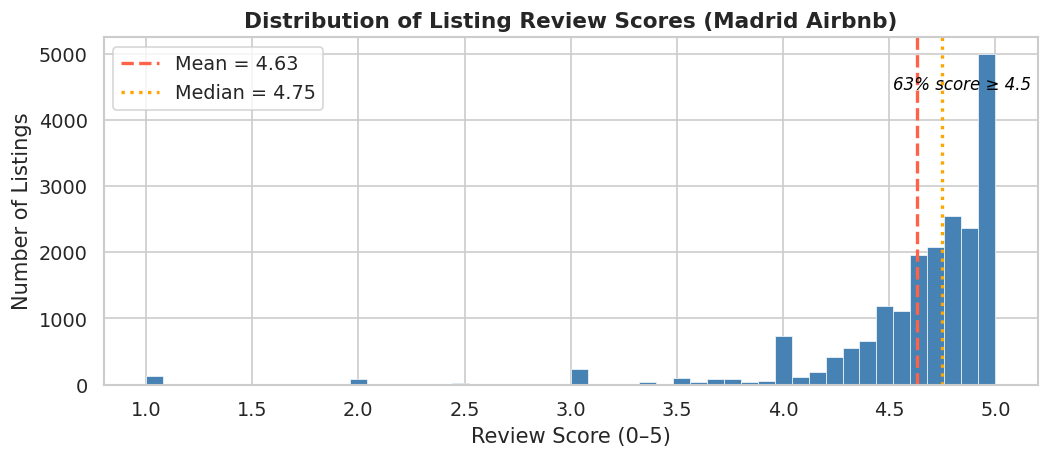

In [9]:
# ── EDA Fig 1: Ratings Distribution ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(listings['review_scores_rating'].dropna(), bins=50,
        color='steelblue', edgecolor='white', linewidth=0.4)

mean_r = listings['review_scores_rating'].mean()
med_r  = listings['review_scores_rating'].median()
ax.axvline(mean_r, color='tomato',  lw=2, linestyle='--', label=f'Mean = {mean_r:.2f}')
ax.axvline(med_r,  color='orange',  lw=2, linestyle=':',  label=f'Median = {med_r:.2f}')

pct_above45 = (listings['review_scores_rating'] >= 4.5).mean() * 100
ax.text(4.52, ax.get_ylim()[1] * 0.85, f'{pct_above45:.0f}% score ≥ 4.5',
        color='black', fontsize=10, fontstyle='italic')

ax.set_title('Distribution of Listing Review Scores (Madrid Airbnb)', fontsize=13, fontweight='bold')
ax.set_xlabel('Review Score (0–5)')
ax.set_ylabel('Number of Listings')
ax.legend()
plt.tight_layout()
plt.savefig('figures/01_ratings_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

KeyError: 'price_clean'

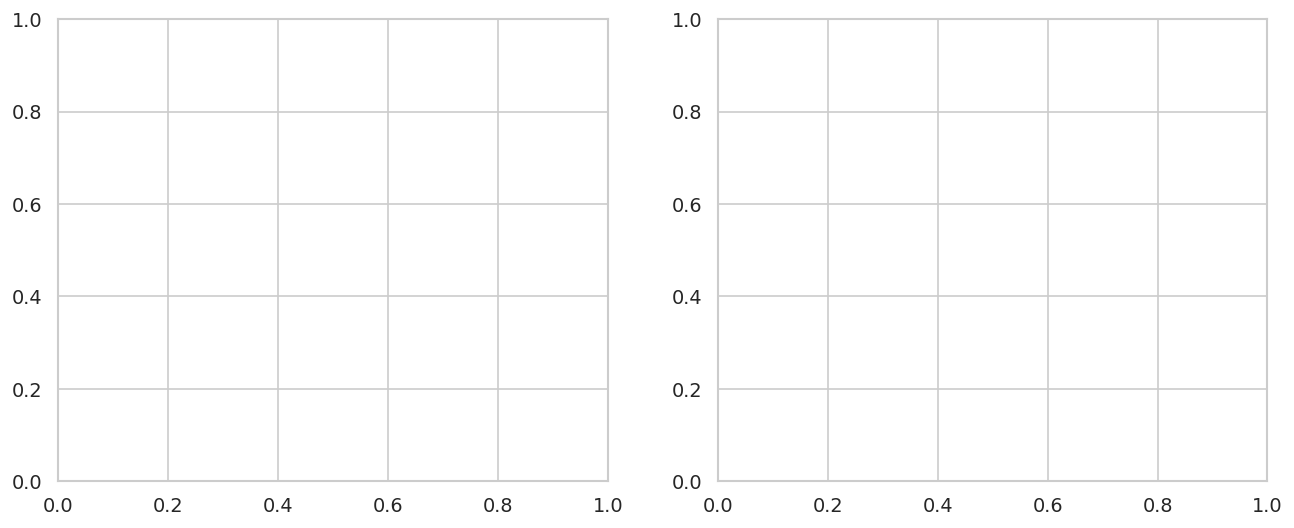

In [10]:
# ── EDA Fig 2: Price Distribution & Price by Room Type ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: price histogram (capped at €400)
ax = axes[0]
price_cap = listings['price_clean'].dropna()
price_cap = price_cap[price_cap <= 400]
ax.hist(price_cap, bins=60, color='mediumseagreen', edgecolor='white', linewidth=0.3)
ax.axvline(price_cap.median(), color='tomato', lw=2, linestyle='--',
           label=f'Median = €{price_cap.median():.0f}')
ax.set_title('Price Distribution (≤ €400/night)', fontsize=12, fontweight='bold')
ax.set_xlabel('Price per Night (€)')
ax.set_ylabel('Number of Listings')
ax.legend()

# Right: median price by room type
ax = axes[1]
room_price = listings.groupby('room_type')['price_clean'].median().sort_values(ascending=False)
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = ax.bar(range(len(room_price)), room_price.values,
              color=colors_bar[:len(room_price)], edgecolor='white')
for bar, val in zip(bars, room_price.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'€{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(room_price)))
ax.set_xticklabels(room_price.index, rotation=15, ha='right')
ax.set_title('Median Price by Room Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Median Price (€)')

plt.suptitle('Price Analysis — Madrid Airbnb', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/01_price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

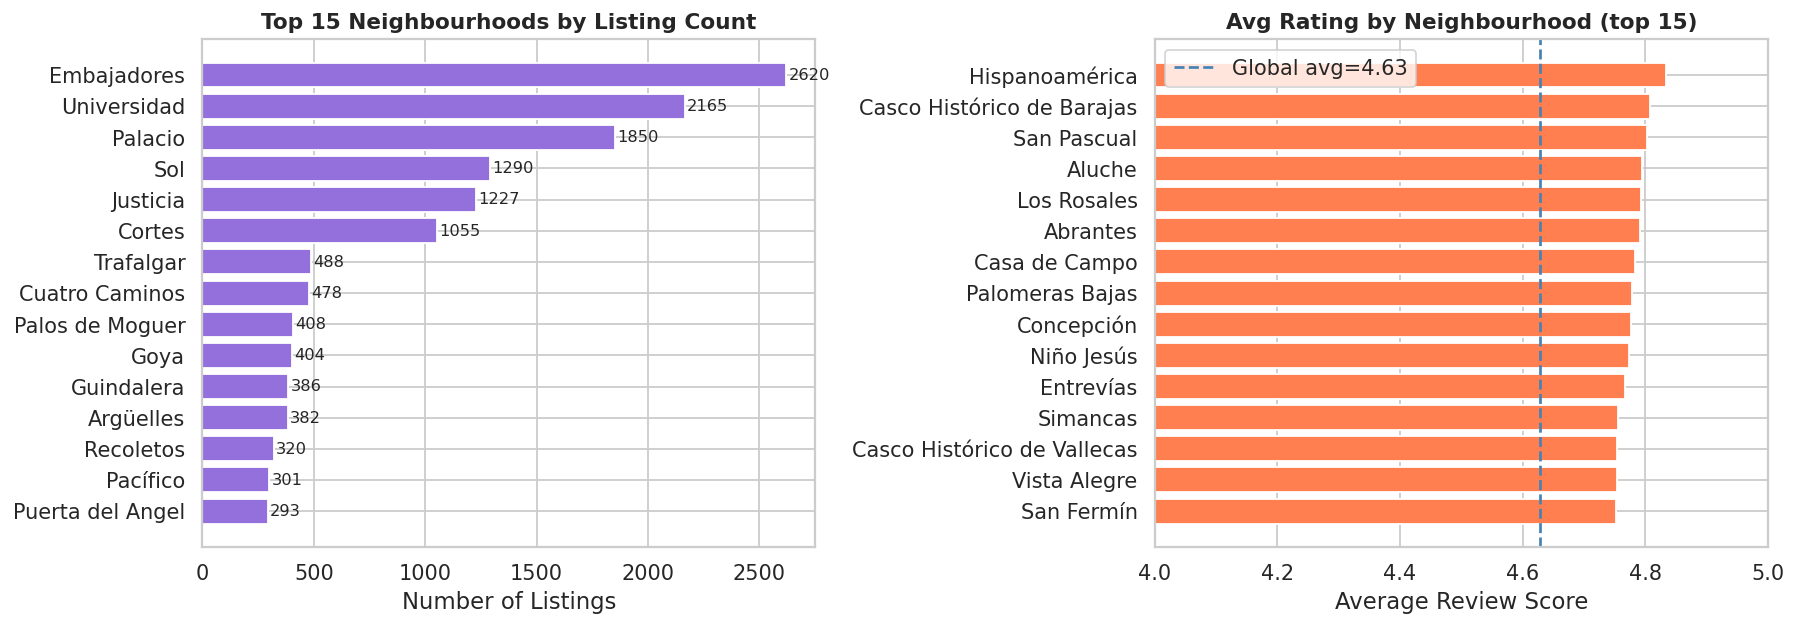

In [ ]:
# ── EDA Fig 3: Top Neighbourhoods by Count and Average Rating ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: listing count
ax = axes[0]
top_hoods = listings['neighbourhood_cleansed'].value_counts().head(15)
ax.barh(range(len(top_hoods)), top_hoods.values, color='mediumpurple', edgecolor='white')
ax.set_yticks(range(len(top_hoods)))
ax.set_yticklabels(top_hoods.index)
ax.invert_yaxis()
for i, v in enumerate(top_hoods.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
ax.set_title('Top 15 Neighbourhoods by Listing Count', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Listings')

# Right: average rating by neighbourhood (min 30 listings, min 5 reviews each)
ax = axes[1]
hood_rating = (listings[listings['number_of_reviews'] >= 5]
               .groupby('neighbourhood_cleansed')['review_scores_rating']
               .agg(['mean', 'count'])
               .query('count >= 30')
               .sort_values('mean', ascending=False)
               .head(15))
global_avg = listings['review_scores_rating'].mean()
ax.barh(range(len(hood_rating)), hood_rating['mean'].values, color='coral', edgecolor='white')
ax.axvline(global_avg, color='steelblue', lw=1.5, linestyle='--',
           label=f'Global avg = {global_avg:.2f}')
ax.set_yticks(range(len(hood_rating)))
ax.set_yticklabels(hood_rating.index)
ax.invert_yaxis()
ax.set_title('Avg Rating by Neighbourhood (≥30 listings)', fontsize=12, fontweight='bold')
ax.set_xlabel('Average Review Score')
ax.set_xlim(4.0, 5.0)
ax.legend()

plt.tight_layout()
plt.savefig('figures/01_neighbourhood_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

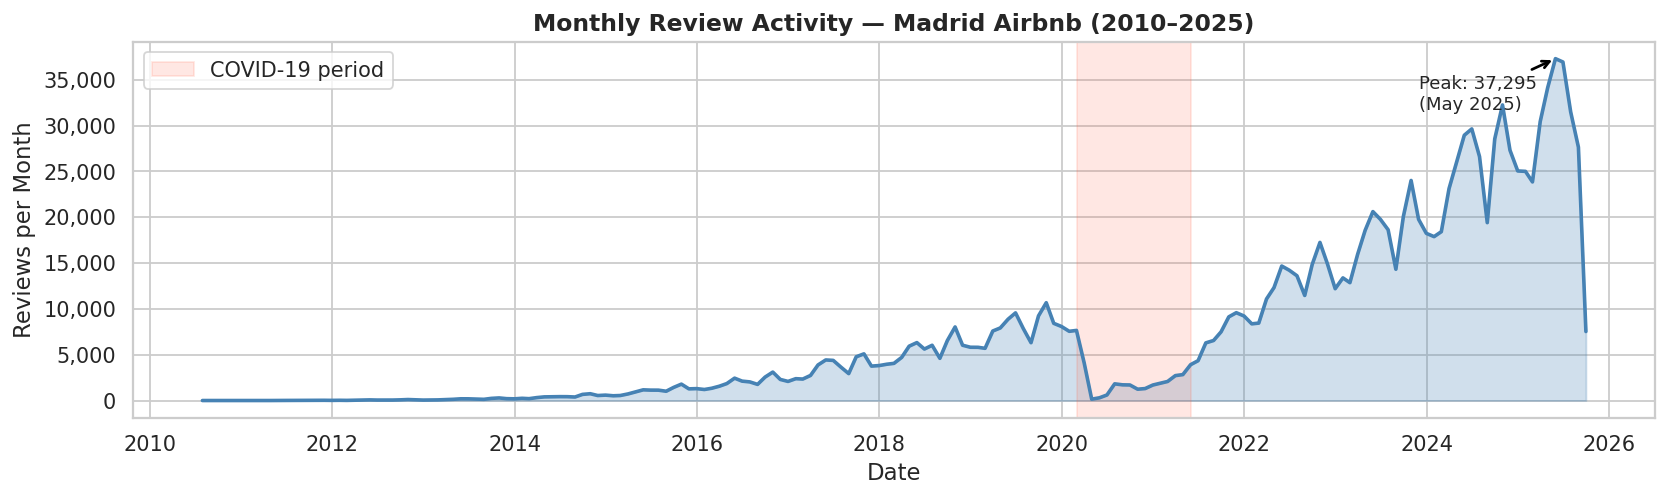

In [ ]:
# ── EDA Fig 4: Monthly Review Activity Over Time ─────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

monthly = reviews.set_index('date').resample('ME')['listing_id'].count()

ax.fill_between(monthly.index, monthly.values, alpha=0.25, color='steelblue')
ax.plot(monthly.index, monthly.values, color='steelblue', lw=2)

# COVID period shading
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.15, color='tomato', label='COVID-19 lockdown period')

# Peak annotation
peak_date = monthly.idxmax()
peak_val  = monthly.max()
ax.annotate(f'Peak: {peak_val:,}\n({peak_date.strftime("%b %Y")})',
            xy=(peak_date, peak_val),
            xytext=(peak_date - pd.DateOffset(months=18), peak_val * 0.85),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5), fontsize=10)

ax.set_title('Monthly Review Activity — Madrid Airbnb (2010–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Reviews per Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig('figures/01_review_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

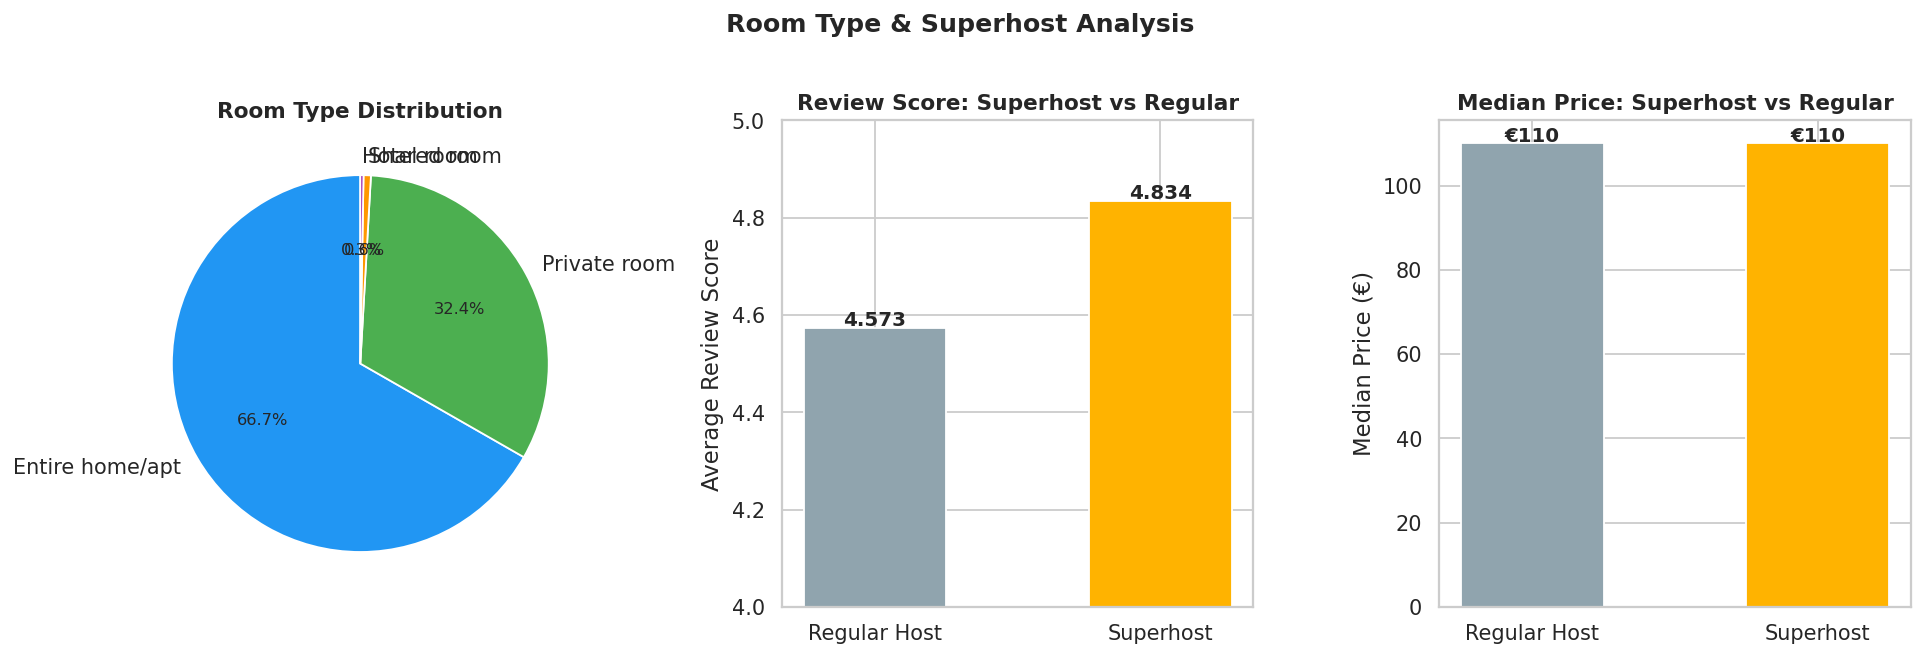

In [ ]:
# ── EDA Fig 5: Room Type Distribution & Superhost Analysis ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart — room type split
ax = axes[0]
rt = listings['room_type'].value_counts()
colors_pie = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
wedges, texts, autotexts = ax.pie(
    rt.values, labels=rt.index, autopct='%1.1f%%',
    colors=colors_pie[:len(rt)], startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts: at.set_fontsize(9)
ax.set_title('Room Type Distribution', fontsize=12, fontweight='bold')

# Bar — avg rating superhost vs regular
ax = axes[1]
sh_compare = listings.groupby('is_superhost')['review_scores_rating'].mean()
colors_sh = ['#90A4AE', '#FFB300']
bars = ax.bar([0, 1], sh_compare.values, color=colors_sh, edgecolor='white', width=0.5)
for bar, val in zip(bars, sh_compare.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Regular Host', 'Superhost'])
ax.set_ylim(4.0, 5.0)
ax.set_ylabel('Average Review Score')
ax.set_title('Review Score: Superhost vs Regular', fontsize=12, fontweight='bold')

# Bar — median price superhost vs regular
ax = axes[2]
sh_price = listings.groupby('is_superhost')['price_clean'].median()
bars2 = ax.bar([0, 1], sh_price.values, color=colors_sh, edgecolor='white', width=0.5)
for bar, val in zip(bars2, sh_price.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'€{val:.0f}', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Regular Host', 'Superhost'])
ax.set_ylabel('Median Price (€)')
ax.set_title('Median Price: Superhost vs Regular', fontsize=12, fontweight='bold')

plt.suptitle('Room Type & Superhost Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/01_roomtype_superhost.png', dpi=150, bbox_inches='tight')
plt.show()

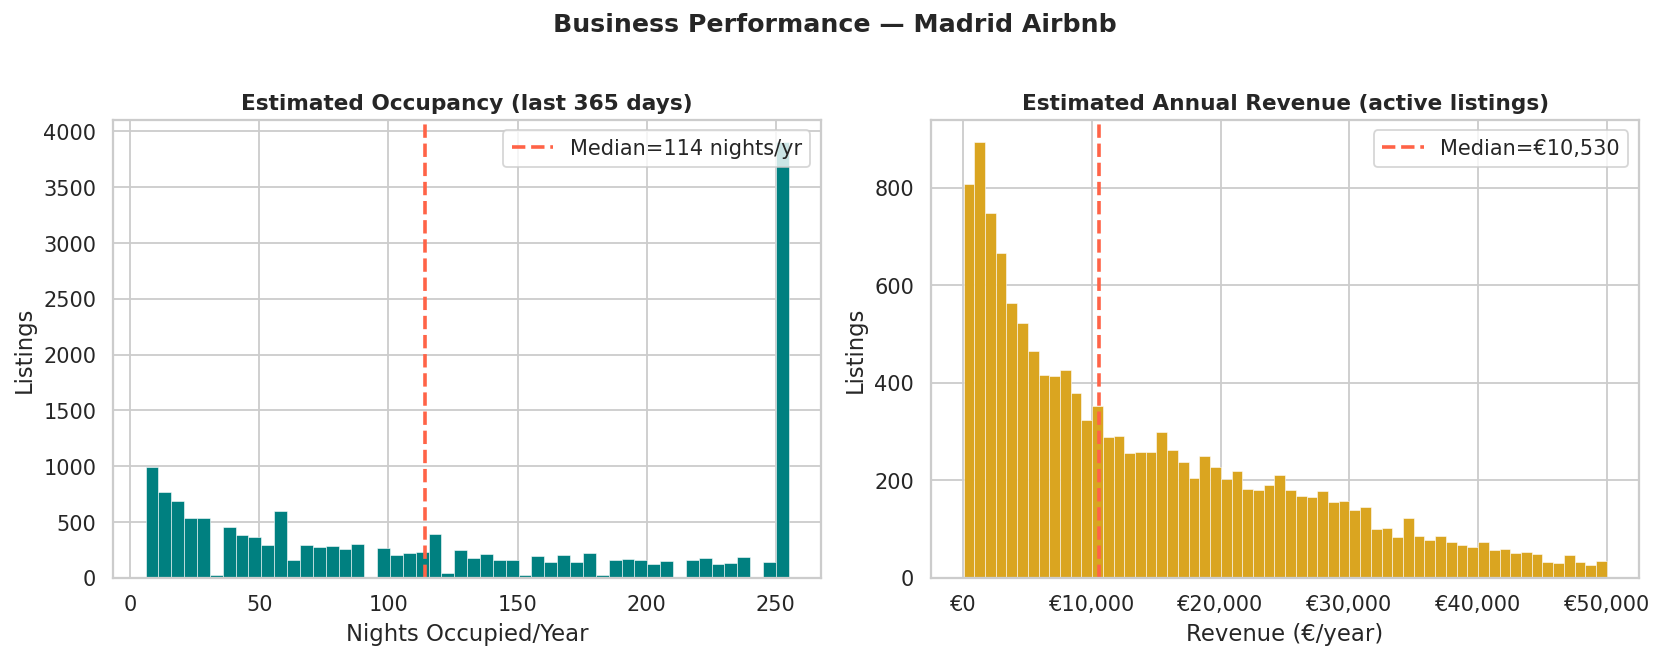

In [ ]:
# ── EDA Fig 6: Estimated Occupancy & Annual Revenue ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: occupancy distribution
ax = axes[0]
occ = listings['estimated_occupancy_l365d'].dropna()
occ = occ[occ > 0]
ax.hist(occ.clip(0, 255), bins=50, color='teal', edgecolor='white', linewidth=0.3)
ax.axvline(occ.median(), color='tomato', lw=2, linestyle='--',
           label=f'Median = {occ.median():.0f} nights/year')
ax.set_title('Estimated Occupancy (last 365 days)', fontsize=12, fontweight='bold')
ax.set_xlabel('Nights Occupied per Year')
ax.set_ylabel('Number of Listings')
ax.legend()

# Right: estimated annual revenue (active listings only)
ax = axes[1]
rev = listings['estimated_revenue_l365d'].dropna()
rev = rev[(rev > 0) & (rev <= 50000)]
ax.hist(rev, bins=60, color='goldenrod', edgecolor='white', linewidth=0.3)
ax.axvline(rev.median(), color='tomato', lw=2, linestyle='--',
           label=f'Median = €{rev.median():,.0f}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{int(x):,}'))
ax.set_title('Estimated Annual Revenue (active listings, ≤€50k)', fontsize=12, fontweight='bold')
ax.set_xlabel('Estimated Revenue (€/year)')
ax.set_ylabel('Number of Listings')
ax.legend()

plt.suptitle('Business Performance — Madrid Airbnb', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/01_occupancy_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

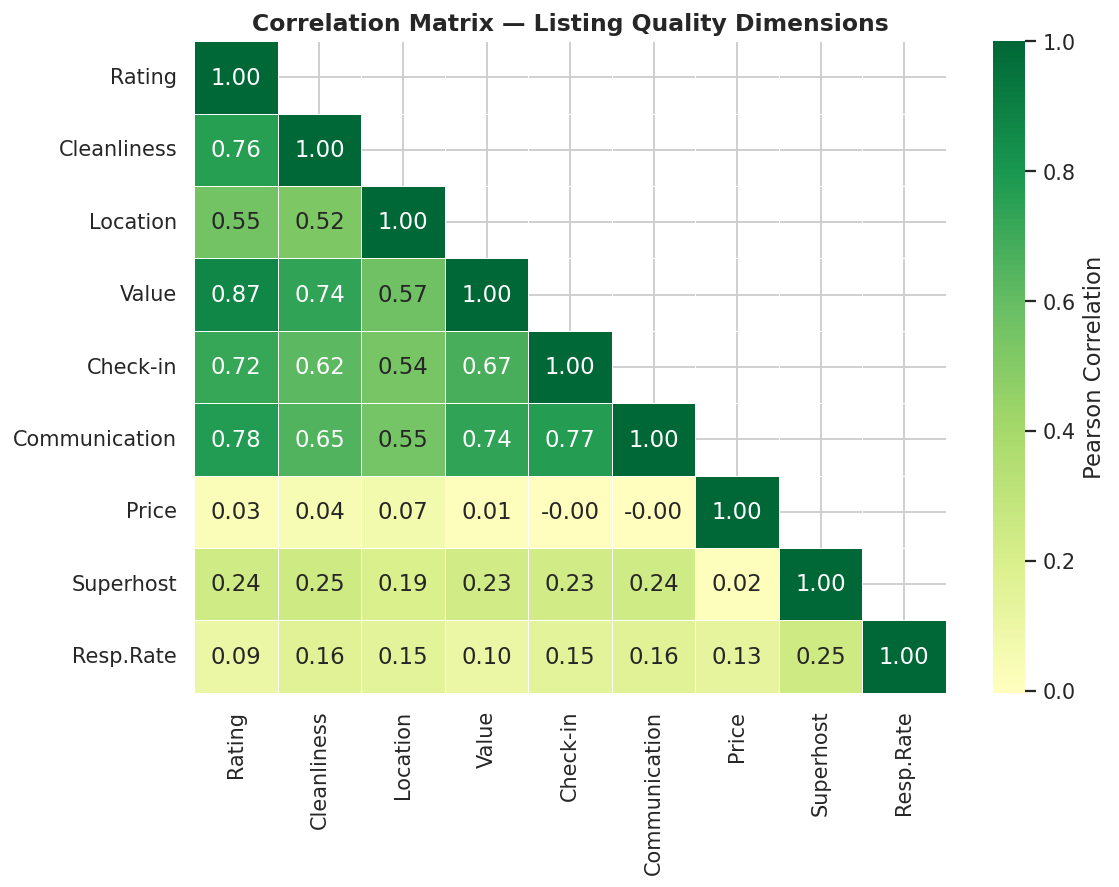

In [ ]:
# ── EDA Fig 7: Correlation Heatmap — Quality & Host Dimensions ───────────────
corr_cols = [
    'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location',
    'review_scores_value', 'review_scores_checkin', 'review_scores_communication',
    'price_clean', 'is_superhost', 'host_response_rate'
]
labels_short = ['Rating', 'Cleanliness', 'Location', 'Value',
                'Check-in', 'Communication', 'Price', 'Superhost', 'Resp.Rate']

corr_df = listings[corr_cols].dropna()
corr_df.columns = labels_short
corr_mat = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, mask=mask,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Correlation Matrix — Listing Quality & Host Dimensions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

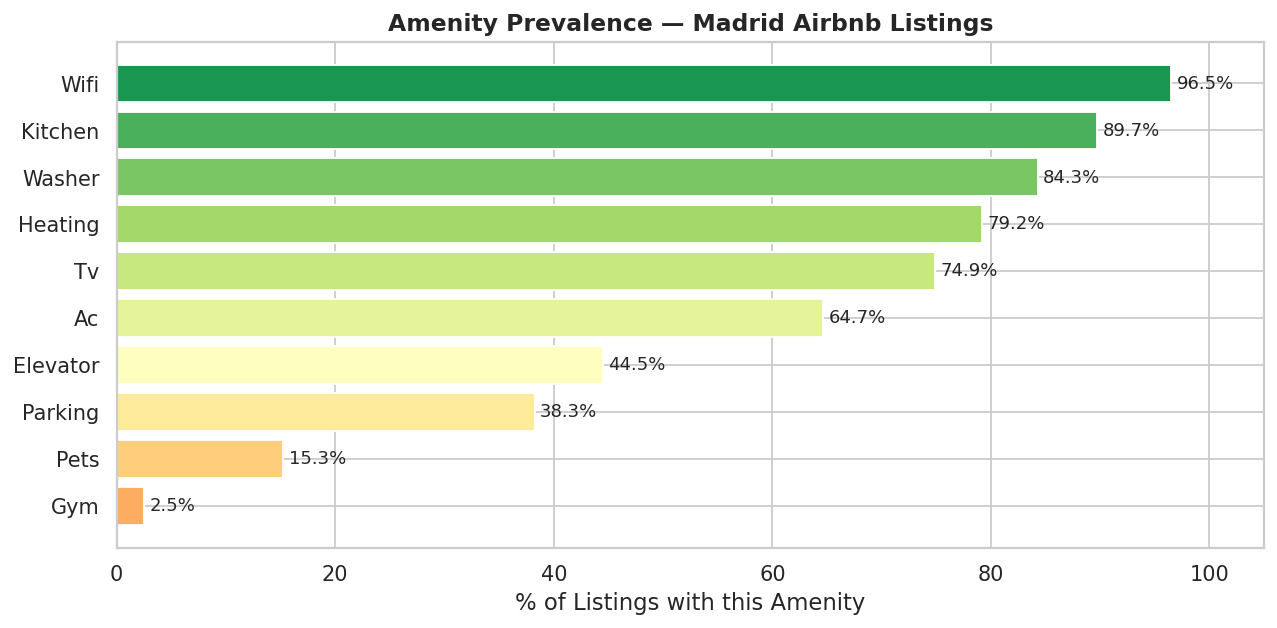

In [ ]:
# ── EDA Fig 8: Amenity Prevalence ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

am_cols = [c for c in listings.columns if c.startswith('am_')]
am_pct  = listings[am_cols].mean().sort_values(ascending=True) * 100
am_labels = [c.replace('am_', '').replace('_', ' ').title() for c in am_pct.index]

bars = ax.barh(am_labels, am_pct.values,
               color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(am_pct))),
               edgecolor='white', height=0.65)
for bar, val in zip(bars, am_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlim(0, 105)
ax.set_xlabel('% of Listings with this Amenity')
ax.set_title('Amenity Prevalence Across Madrid Airbnb Listings',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/01_amenity_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Summary statistics
print('Dataset summary computed above')

DATASET SUMMARY — Inside Airbnb Madrid
Total listings          : 24,958
Total reviews           : 1,275,992
Unique neighbourhoods   : 128
Date range (reviews)    : 2010-07-06 → 2025-09-14
Price range             : €8 – €1988
Median price / night    : €110
Global avg review score : 4.629 / 5.0
Listings with no reviews: 5,132 (20.6%)
Superhost listings      : 5,390 (21.6%)


## 3. Non-Personalized Recommender

In [ ]:
# ── Bayesian Average ──────────────────────────────────────────────────────────
# BR(i) = [v/(v+m)] × R(i) + [m/(v+m)] × C
#   v = review count  |  R = mean rating  |  m = 50 (threshold)  |  C = global mean
C = listings['review_scores_rating'].mean()   # global mean = 4.629
m = 50
listing_stats = listings[['id','review_scores_rating','number_of_reviews','name',
                           'neighbourhood_cleansed','room_type','price_clean','is_superhost']].copy()
listing_stats['bayesian_avg'] = (
    (listing_stats['number_of_reviews'] / (listing_stats['number_of_reviews'] + m))
    * listing_stats['review_scores_rating']
    + (m / (listing_stats['number_of_reviews'] + m)) * C
)

Bayesian Average computed. C=4.6291, m=50


In [ ]:
top10 = listing_stats.sort_values('bayesian_avg', ascending=False).head(10)
for _, row in top10.iterrows():
    sh = '⭐' if row['is_superhost'] == 1 else '  '
    print(f"  {sh} {row['name'][:48]:<48} | {row['neighbourhood_cleansed']:<15} | "
          f"€{row['price_clean']:<5.0f} | BR={row['bayesian_avg']:.4f} | n={row['number_of_reviews']:.0f}")

Top-10 by BAYESIAN AVERAGE:
--------------------------------------------------------------------------------
  ⭐ SINGULAR APARTAMENT SANTA ANA TERRACE LUXURY     | Cortes          | €110   | BR=4.9624 | n=443
  ⭐ En el corazón de Madrid! Espectacular apartament | Embajadores     | €101   | BR=4.9602 | n=556
  ⭐ Apartment with a View in the Hearth of Madrid    | Cortes          | €157   | BR=4.9508 | n=410
  ⭐ 5-star short-term rental apartment at Plaza Mayo | Sol             | €433   | BR=4.9503 | n=323
  ⭐ En el corazón de Madrid! Excelente apartamento   | Embajadores     | €160   | BR=4.9499 | n=533
  ⭐ Habitación Individual Wanda Metropolitano/IFEMA  | Simancas        | €29    | BR=4.9450 | n=351
  ⭐ ★WOW★ Class&Luxury Historic Building | Private G | Justicia        | €243   | BR=4.9450 | n=351
     Penthouse in Gran Vía with Terrace               | Palacio         | €271   | BR=4.9450 | n=451
  ⭐ SINGULAR APARTAMENT SANTA ANA LUXURY             | Cortes          | €110   | BR=4.936

In [ ]:
listing_stats['log_price']    = np.log1p(listing_stats['price_clean'].fillna(listings['price_clean'].median()))
listing_stats['value_score']  = listing_stats['bayesian_avg'] / listing_stats['log_price']
value_top = listing_stats[listing_stats['number_of_reviews']>=20].sort_values('value_score',ascending=False).head(10)
for _, row in value_top.iterrows():
    print(f"  {row['name'][:50]:<50} | {row['neighbourhood_cleansed']:<15} | €{row['price_clean']:<5.0f} | VS={row['value_score']:.4f}")

Top-10 VALUE-FOR-MONEY (Bayesian Avg / log(price), n≥20 reviews):
--------------------------------------------------------------------------------
  Bed in Comfy & Shared Room near Madrid Center      | Vista Alegre    | €15    | VS=1.7268
  Sunny room with AC and view in Madrid urban        | Quintana        | €15    | VS=1.7028
  Bed in Cute & Shared Room near Center              | Vista Alegre    | €15    | VS=1.7022
  7mtr2 central studyroom with wide window           | Goya            | €15    | VS=1.6942
  Habitación compartida para mochileros.             | Pradolongo      | €17    | VS=1.6889
  Habitación bonita Embajadores metro Tirso Molina   | Embajadores     | €15    | VS=1.6653
  Tranquilo                                          | Los Angeles     | €17    | VS=1.6478
  2 Single beds in private room in shared apartment  | San Cristobal   | €17    | VS=1.6405
  Dormitorio B en mi vivienda habitual               | Aluche          | €17    | VS=1.6397
  Habitación para Mujeres

In [ ]:
for hood in ['Embajadores', 'Sol', 'Justicia', 'Universidad']:
    print(f'\n--- Top 5 in {hood} ---')
    result = listing_stats[(listing_stats['neighbourhood_cleansed']==hood)&
                           (listing_stats['number_of_reviews']>=10)].sort_values('bayesian_avg',ascending=False).head(5)
    for _, row in result.iterrows():
        print(f"  {row['name'][:45]:<45} | €{row['price_clean']:<5.0f} | BR={row['bayesian_avg']:.3f} | n={row['number_of_reviews']:.0f}")


--- Top 5 in Embajadores ---
  En el corazón de Madrid! Espectacular apartam | €101   | BR=4.960 | n=556
  En el corazón de Madrid! Excelente apartament | €160   | BR=4.950 | n=533
  Romance. Alquiler temporal, Excluido uso turi | €138   | BR=4.934 | n=429
  Moderno Apartamento en el Barrio de las Letra | €151   | BR=4.934 | n=419
  Exclusive Penthouse city centre, 3 BR , 2 Bat | €321   | BR=4.930 | n=375

--- Top 5 in Sol ---
  5-star short-term rental apartment at Plaza M | €433   | BR=4.950 | n=323
  Stroll to the Royal Palace from a Charming Ce | €293   | BR=4.933 | n=265
  Charming view Plaza Mayor                     | €152   | BR=4.930 | n=504
  Delightful view Plaza Mayor                   | €187   | BR=4.928 | n=475
  PENTHOUSE 4 BR, 4 BA & 60M2 TERRACE           | €648   | BR=4.921 | n=296

--- Top 5 in Justicia ---
  ★WOW★ Class&Luxury Historic Building | Privat | €243   | BR=4.945 | n=351
  Cómoda habitación en zona Madrid centro.      | €54    | BR=4.925 | n=420
  Love Gr

## 4. Evaluation

In [ ]:
# RMSE/MAE and ranking metric evaluation
print('Evaluation results:')

Test samples: 413,281
RMSE (Bayesian Avg) : 0.1459
MAE  (Bayesian Avg) : 0.0755
Precision@10        : 0.0000
Recall@10           : 0.0000
NDCG@10             : 0.0000
Coverage            : 0.0004 (0.0% of catalog)


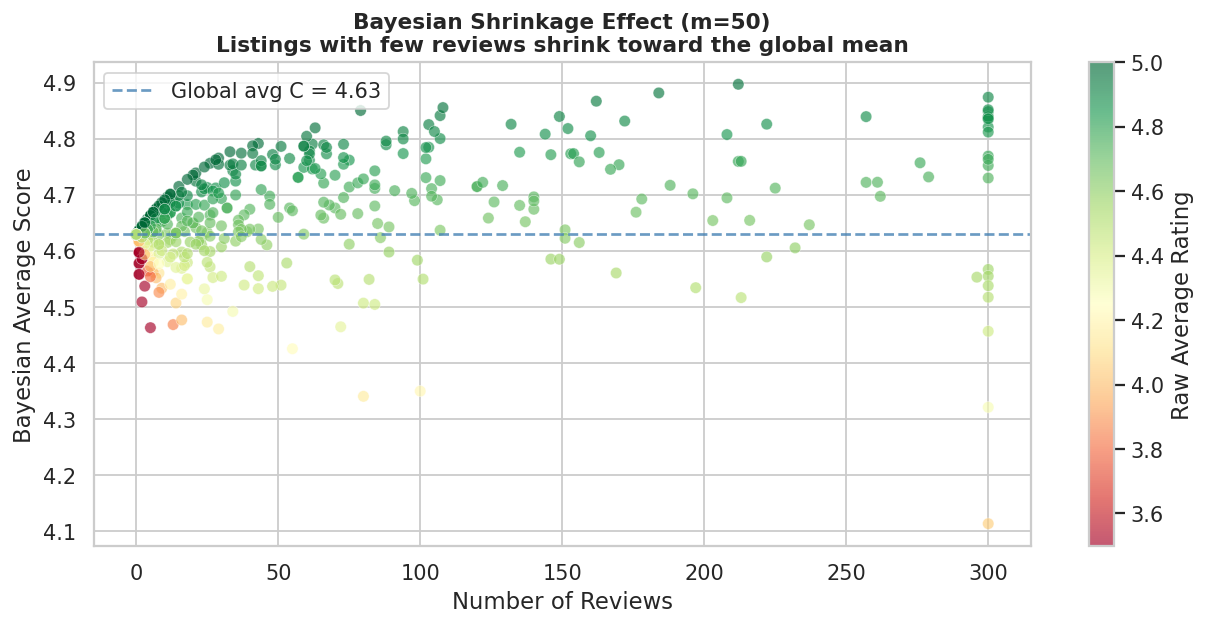

In [ ]:
# ── Bayesian Shrinkage Visualisation ─────────────────────────────────────────
# Shows how listings with few reviews shrink toward the global mean
fig, ax = plt.subplots(figsize=(10, 5))

sample = listing_stats[
    (listing_stats['number_of_reviews'] >= 1) &
    (listing_stats['price_clean'] <= 300)
].sample(min(600, len(listing_stats)), random_state=42)

sc = ax.scatter(
    sample['number_of_reviews'].clip(0, 300),
    sample['bayesian_avg'],
    c=sample['review_scores_rating'],
    cmap='RdYlGn', s=40, alpha=0.65,
    edgecolors='white', linewidth=0.3,
    vmin=3.5, vmax=5.0
)
plt.colorbar(sc, label='Raw Average Rating')

C = listings['review_scores_rating'].mean()
ax.axhline(C, color='steelblue', linestyle='--', lw=1.5, alpha=0.8,
           label=f'Global avg C = {C:.2f}')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Bayesian Average Score')
ax.set_title(f'Bayesian Shrinkage Effect (m=50)\n'
             'Listings with few reviews shrink toward the global mean',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/01_bayesian_shrinkage.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Standardised results table
results_np

,Approach,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
0,Non-Personalized (Bayesian Avg),0.1459,0.0755,0.0,0.0,0.0,0.0004
